# U4 — Linear Algebra: Lab

**The language of data, models & transformations** — vectors · matrices · tensors · norms · transformations · eigenvectors · rank

_Day 2 · Phase B — Mathematical Foundations · Built from Module 1.3_

#objectives

By the end of this lab you will be able to:

Represent data as scalars, vectors, matrices and tensors, and do tensor ops (add, transpose, reshape)

Compute dot/cross products, L1/L2/L-infinity norms and cosine similarity

Work with matrix operations and special matrices (inverse, trace, symmetric, orthogonal)

Apply transformations (scaling, rotation) and plot the result

Find eigenvalues and eigenvectors and verify A v = lambda v

Solve a linear system, read its rank, and use cosine similarity on embeddings

#how to use this lab

Each section has two kinds of cells:

Worked demo cells — run them top to bottom and read the comments to learn the pattern.

LAB EXERCISE cells (marked 🧪) — your turn. Replace each `# YOUR CODE HERE` with working code.

Run cells with **Shift + Enter**. Run the demos before attempting the exercises.

In [1]:
# Core imports for the whole lab
import numpy as np
import numpy.linalg as la          # inv, norm, eig, solve, matrix_rank
import matplotlib.pyplot as plt

np.set_printoptions(precision=3, suppress=True)   # tidy array printing
np.random.seed(42)
print('Setup complete. NumPy', np.__version__)

Setup complete. NumPy 2.0.2


#1. Scalars, vectors, matrices & tensors

In [2]:
# -----------------------------------------------------------
# 🔹 1A. THE FOUR CONTAINERS
# -----------------------------------------------------------

scalar = np.array(5)                  # 0-D: a single number
vector = np.array([2, 5, 1])          # 1-D: a list of numbers
matrix = np.array([[1, 2], [3, 4]])   # 2-D: rows x columns
tensor = np.ones((3, 2, 2))           # n-D: a stack of matrices

# .ndim = number of dimensions, .shape = size along each dimension
for name, arr in [('scalar', scalar), ('vector', vector),
                  ('matrix', matrix), ('tensor', tensor)]:
    print(f'{name:7s} ndim={arr.ndim}  shape={arr.shape}')

scalar  ndim=0  shape=()
vector  ndim=1  shape=(3,)
matrix  ndim=2  shape=(2, 2)
tensor  ndim=3  shape=(3, 2, 2)


In [44]:
# -----------------------------------------------------------
# 🔹 1B. TENSOR OPERATIONS: add, transpose, reshape
# -----------------------------------------------------------

A = np.arange(6).reshape(2, 3)   # shape (2, 3)
B = np.ones((2, 3), dtype=int)

print('A:\n', A)
print('A + B (element-wise add):\n', A + B)
print('A.T  (transpose -> shape', A.T.shape, '):\n', A.T)
print('A.reshape(3, 2):\n', A.reshape(3, 2))
print('A.flatten():', A.flatten())

A:
 [[0 1 2]
 [3 4 5]]
A + B (element-wise add):
 [[1 2 3]
 [4 5 6]]
A.T  (transpose -> shape (3, 2) ):
 [[0 3]
 [1 4]
 [2 5]]
A.reshape(3, 2):
 [[0 1]
 [2 3]
 [4 5]]
A.flatten(): [0 1 2 3 4 5]


#### 🧪 LAB EXERCISE 1 — Tensor ops: add, transpose, reshape

Using the array `T` provided below:
1. Print its `ndim` and `shape`.
2. Add `T` to itself and print the result.
3. Transpose `T` and print the new shape, then reshape `T` into shape `(2, 6)`.

In [45]:
T = np.arange(12).reshape(3, 4)
print('T:\n', T)

# 1. ndim and shape
print('T ndim:', T.ndim)
print('T shape:', T.shape)

# 2. T + T
print('T + T:\n', T + T)

# 3. Transpose (print .T.shape) and reshape to (2, 6)
T_transposed = T.T
print('T Transposed shape:', T_transposed.shape)
print('T Reshaped to (2, 6):\n', T.reshape(2, 6))

T:
 [[ 0  1  2  3]
 [ 4  5  6  7]
 [ 8  9 10 11]]
T ndim: 2
T shape: (3, 4)
T + T:
 [[ 0  2  4  6]
 [ 8 10 12 14]
 [16 18 20 22]]
T Transposed shape: (4, 3)
T Reshaped to (2, 6):
 [[ 0  1  2  3  4  5]
 [ 6  7  8  9 10 11]]


#2. Dot & cross products, and norms

In [8]:
# -----------------------------------------------------------
# 🔹 2A. DOT & CROSS PRODUCTS
# -----------------------------------------------------------

a = np.array([1, 2, 3])
b = np.array([4, 0, 1])

# Dot product: sum of element-wise products -> measures alignment
print('a . b  (dot)   :', np.dot(a, b))      # 1*4 + 2*0 + 3*1 = 7

# Cross product: a new vector perpendicular to both (3-D only)
print('a x b  (cross) :', np.cross(a, b))

a . b  (dot)   : 7
a x b  (cross) : [ 2 11 -8]


In [10]:
# -----------------------------------------------------------
# 🔹 2B. NORMS (vector length) + COSINE SIMILARITY
# -----------------------------------------------------------

print('L2 norm  ||a||_2 :', la.norm(a))         # sqrt(sum of squares)
print('L1 norm  ||a||_1 :', la.norm(a, 1))      # sum of absolute values
print('Linf norm        :', la.norm(a, np.inf)) # max absolute value

# Cosine similarity: the angle between vectors, ignoring magnitude
def cosine(u, v):
    return np.dot(u, v) / (la.norm(u) * la.norm(v))

print('cosine(a, b)     :', round(cosine(a, b), 3))

L2 norm  ||a||_2 : 3.7416573867739413
L1 norm  ||a||_1 : 6.0
Linf norm        : 3.0
cosine(a, b)     : 0.454


#### 🧪 LAB EXERCISE 2 — L1/L2 norms + cosine similarity on 3 vector pairs

Three vector pairs are provided in `pairs`. For each pair `(u, v)`:
1. Print the **L1** and **L2** norm of `u`.
2. Print the **cosine similarity** between `u` and `v` (reuse the `cosine` function above).
3. Which pair is the most similar? Note it in a comment.

In [46]:
pairs = [
    (np.array([1, 0, 1]), np.array([1, 0, 1])),    # pair 1
    (np.array([1, 2, 3]), np.array([3, 2, 1])),    # pair 2
    (np.array([2, 0, 0]), np.array([0, 5, 0])),    # pair 3
]

# Dictionary to store cosine similarities for finding the most similar pair
cosine_similarities = {}

for i, (u, v) in enumerate(pairs, start=1):
    print(f'\n--- Pair {i} ---')
    # 1. L1 and L2 norm of u
    l1_norm_u = la.norm(u, 1)
    l2_norm_u = la.norm(u)
    print(f'L1 norm of u: {l1_norm_u}')
    print(f'L2 norm of u: {l2_norm_u}')

    # 2. cosine similarity of u and v
    sim = cosine(u, v)
    print(f'Cosine similarity of u and v: {sim:.3f}')
    cosine_similarities[f'Pair {i}'] = sim

# 3. Most similar pair = ?   (write your answer here)
# Find the pair with the highest cosine similarity
most_similar_pair = max(cosine_similarities, key=cosine_similarities.get)
print(f'\nMost similar pair: {most_similar_pair} (Cosine Similarity: {cosine_similarities[most_similar_pair]:.3f})')



--- Pair 1 ---
L1 norm of u: 2.0
L2 norm of u: 1.4142135623730951
Cosine similarity of u and v: 1.000

--- Pair 2 ---
L1 norm of u: 6.0
L2 norm of u: 3.7416573867739413
Cosine similarity of u and v: 0.714

--- Pair 3 ---
L1 norm of u: 2.0
L2 norm of u: 2.0
Cosine similarity of u and v: 0.000

Most similar pair: Pair 1 (Cosine Similarity: 1.000)


#3. Matrix operations & special matrices

In [47]:
# -----------------------------------------------------------
# 🔹 3A. CORE MATRIX OPERATIONS
# -----------------------------------------------------------

A = np.array([[2., 3.],
              [5., 3.]])
B = np.array([[1., 0.],
              [4., 2.]])

print('A @ B (matrix multiply):\n', A @ B)
print('A.T   (transpose):\n', A.T)
print('inverse(A):\n', la.inv(A))
print('trace(A) = sum of diagonal:', np.trace(A))

A @ B (matrix multiply):
 [[14.  6.]
 [17.  6.]]
A.T   (transpose):
 [[2. 5.]
 [3. 3.]]
inverse(A):
 [[-0.333  0.333]
 [ 0.556 -0.222]]
trace(A) = sum of diagonal: 5.0


In [22]:
# -----------------------------------------------------------
# 🔹 3B. SPECIAL MATRICES: identity, symmetric, orthogonal
# -----------------------------------------------------------

I = np.eye(2)                       # identity: 1s on the diagonal
print('Identity I:\n', I)
print('A @ inv(A) == I ?', np.allclose(A @ la.inv(A), I))

# Symmetric: A equals its own transpose
print('A symmetric?', np.allclose(A, A.T))

# Orthogonal: Q.T @ Q == I (a pure rotation/reflection)
theta = np.radians(30)
Q = np.array([[np.cos(theta), -np.sin(theta)],
              [np.sin(theta),  np.cos(theta)]])
print('Q orthogonal?', np.allclose(Q.T @ Q, I))

Identity I:
 [[1. 0.]
 [0. 1.]]
A @ inv(A) == I ? True
A symmetric? False
Q orthogonal? True


#### 🧪 LAB EXERCISE 3 — Inverse, trace, and matrix tests

Using matrix `M` below:
1. Print `inverse(M)` and `trace(M)`.
2. Verify that `M @ inverse(M)` is the identity (use `np.allclose`).
3. Test whether `M` is **symmetric** and whether `P` (provided) is **orthogonal**.

In [48]:
M = np.array([[4., 2.],
              [2., 3.]])
P = np.array([[0., -1.],
              [1.,  0.]])   # a 90-degree rotation

# 1. inverse and trace of M
inv_M = la.inv(M)
print('inverse(M):\n', inv_M)
print('trace(M):', np.trace(M))

# 2. M @ inv(M) == I ?
I = np.eye(2) # Identity matrix for comparison
print('M @ inv(M) == I ?', np.allclose(M @ inv_M, I))

# 3. Is M symmetric? Is P orthogonal?
print('M symmetric?', np.allclose(M, M.T))
print('P orthogonal?', np.allclose(P.T @ P, I))

inverse(M):
 [[ 0.375 -0.25 ]
 [-0.25   0.5  ]]
trace(M): 7.0
M @ inv(M) == I ? True
M symmetric? True
P orthogonal? True


#4. Transformations: rotation & scaling

In [51]:
# -----------------------------------------------------------
# 🔹 4A. BUILD TRANSFORMATION MATRICES
# -----------------------------------------------------------

# A unit square defined by its 4 corners (each column is a point)
square = np.array([[0, 1, 1, 0],
                   [0, 0, 1, 1]], dtype=float)

# Scaling matrix: stretch x by 1.5, y by 0.5
S = np.array([[1.5, 0.0],
              [0.0, 0.5]])

# Rotation matrix: rotate by 30 degrees
t = np.radians(30)
R = np.array([[np.cos(t), -np.sin(t)],
              [np.sin(t),  np.cos(t)]])

scaled  = S @ square      # apply scaling
rotated = R @ square      # apply rotation
print('Rotated corners:\n', rotated)

Rotated corners:
 [[ 0.     0.866  0.366 -0.5  ]
 [ 0.     0.5    1.366  0.866]]


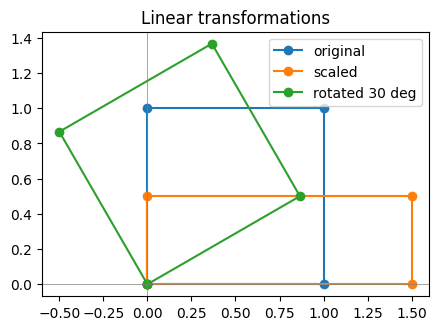

In [50]:
# -----------------------------------------------------------
# 🔹 4B. PLOT ORIGINAL vs TRANSFORMED
# -----------------------------------------------------------

def close_loop(pts):
    # repeat the first point at the end so the polygon closes
    return np.hstack([pts, pts[:, :1]])

fig, ax = plt.subplots(figsize=(5, 5))
ax.plot(*close_loop(square),  marker='o', label='original')
ax.plot(*close_loop(scaled),  marker='o', label='scaled')
ax.plot(*close_loop(rotated), marker='o', label='rotated 30 deg')
ax.axhline(0, color='gray', lw=0.5); ax.axvline(0, color='gray', lw=0.5)
ax.set_aspect('equal'); ax.legend(); ax.set_title('Linear transformations')
plt.show()

#### 🧪 LAB EXERCISE 4 — Apply 2 transformations & plot

Start from the `tri` triangle below:
1. Build a **scaling** matrix that doubles `x` and halves `y`.
2. Build a **rotation** matrix for 45 degrees.
3. Apply both (one after another) and plot the original vs the transformed triangle.

_Hint: reuse `close_loop` and the plotting pattern from 4B._

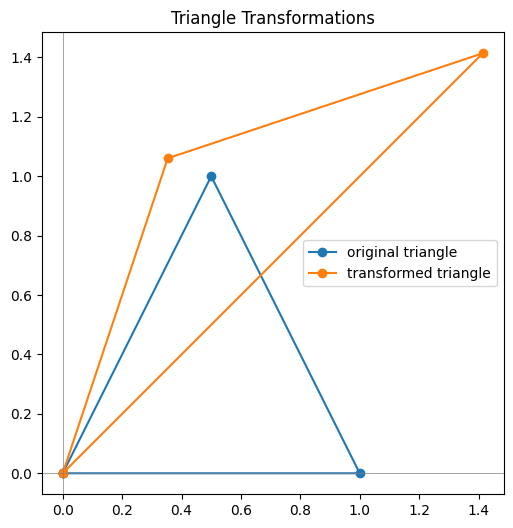

In [52]:
tri = np.array([[0, 1, 0.5],
                [0, 0, 1.0]])   # 3 corners of a triangle

# Define close_loop function locally for this exercise
def close_loop(pts):
    # repeat the first point at the end so the polygon closes
    return np.hstack([pts, pts[:, :1]])

# 1. Scaling matrix (x*2, y*0.5)
S_ex4 = np.array([[2.0, 0.0],
                  [0.0, 0.5]])

# 2. Rotation matrix (45 degrees)
t_ex4 = np.radians(45)
R_ex4 = np.array([[np.cos(t_ex4), -np.sin(t_ex4)],
                  [np.sin(t_ex4),  np.cos(t_ex4)]])

# 3. Apply both and plot original vs transformed
transformed_tri = R_ex4 @ (S_ex4 @ tri)

fig_ex4, ax_ex4 = plt.subplots(figsize=(6, 6))
ax_ex4.plot(*close_loop(tri),  marker='o', label='original triangle')
ax_ex4.plot(*close_loop(transformed_tri),  marker='o', label='transformed triangle')
ax_ex4.axhline(0, color='gray', lw=0.5); ax_ex4.axvline(0, color='gray', lw=0.5)
ax_ex4.set_aspect('equal'); ax_ex4.legend(); ax_ex4.set_title('Triangle Transformations')
plt.show()

#5. Eigenvalues & eigenvectors

For a matrix `A`, an **eigenvector** `v` is a direction that `A` only stretches (never rotates), and the **eigenvalue** `lambda` is how much it stretches it:  **A v = lambda v**.

In [53]:
# -----------------------------------------------------------
# 🔹 5A. COMPUTE EIGENVALUES & EIGENVECTORS
# -----------------------------------------------------------

A = np.array([[2., 0.],
              [0., 3.]])

vals, vecs = la.eig(A)     # vals = eigenvalues, vecs columns = eigenvectors
print('Eigenvalues  (lambda):', vals)
print('Eigenvectors (columns):\n', vecs)

Eigenvalues  (lambda): [2. 3.]
Eigenvectors (columns):
 [[1. 0.]
 [0. 1.]]


In [54]:
# -----------------------------------------------------------
# 🔹 5B. VERIFY  A v = lambda v
# -----------------------------------------------------------

for i in range(len(vals)):
    v = vecs[:, i]                 # i-th eigenvector
    lhs = A @ v                    # A v
    rhs = vals[i] * v              # lambda v
    print(f'lambda={vals[i]:.1f}  A v == lambda v ?', np.allclose(lhs, rhs))

lambda=2.0  A v == lambda v ? True
lambda=3.0  A v == lambda v ? True


#### 🧪 LAB EXERCISE 5 — Eigenvalues/vectors & verification

Using matrix `C` below:
1. Compute its eigenvalues and eigenvectors with `la.eig`.
2. Print the eigenvalues.
3. Verify `C @ v == lambda * v` for the **first** eigenvector using `np.allclose`.

In [55]:
C = np.array([[4., 1.],
              [2., 3.]])

# 1. eigenvalues and eigenvectors
vals, vecs = la.eig(C)

# 2. print eigenvalues
print('Eigenvalues (lambda):', vals)
print('Eigenvectors (columns):\n', vecs)

# 3. verify C @ v = lambda * v for the first eigenvector
v1 = vecs[:, 0]                 # First eigenvector
lambda1 = vals[0]               # First eigenvalue

lhs = C @ v1
rhs = lambda1 * v1

print(f'\nVerification for first eigenvector (lambda={lambda1:.2f}): C @ v == lambda * v ?', np.allclose(lhs, rhs))

Eigenvalues (lambda): [5. 2.]
Eigenvectors (columns):
 [[ 0.707 -0.447]
 [ 0.707  0.894]]

Verification for first eigenvector (lambda=5.00): C @ v == lambda * v ? True


#6. Rank, solving systems & cosine similarity

In [56]:
# -----------------------------------------------------------
# 🔹 6A. SOLVE A 3x3 SYSTEM  A x = b
# -----------------------------------------------------------

A = np.array([[ 2.,  1., -1.],
              [-3., -1.,  2.],
              [-2.,  1.,  2.]])
b = np.array([8., -11., -3.])

x = la.solve(A, b)
print('Solution x:', x)                    # [2, 3, -1]
print('Rank of A :', la.matrix_rank(A))     # 3 -> full rank
print('Full rank -> a unique solution exists')

Solution x: [ 2.  3. -1.]
Rank of A : 3
Full rank -> a unique solution exists


In [57]:
# -----------------------------------------------------------
# 🔹 6B. RANK TELLS YOU SOLVABILITY
# -----------------------------------------------------------

# A rank-deficient matrix: row 3 = row 1 + row 2 (not independent)
D = np.array([[1., 2., 3.],
              [4., 5., 6.],
              [5., 7., 9.]])
print('Rank of D:', la.matrix_rank(D), '-> < 3, so rows are dependent')

Rank of D: 2 -> < 3, so rows are dependent


In [58]:
# -----------------------------------------------------------
# 🔹 6C. COSINE SIMILARITY ON 'EMBEDDINGS'
# -----------------------------------------------------------

# Toy 4-D embeddings (in practice these come from a model)
king  = np.array([0.8, 0.6, 0.1, 0.2])
queen = np.array([0.7, 0.7, 0.1, 0.3])
apple = np.array([0.1, 0.0, 0.9, 0.8])

print('cosine(king, queen):', round(cosine(king, queen), 3))   # high
print('cosine(king, apple):', round(cosine(king, apple), 3))   # low

cosine(king, queen): 0.986
cosine(king, apple): 0.267


#### 🧪 LAB EXERCISE 6 — Solve a system + compare embeddings

1. Solve the 2x2 system `A2 x = b2` (given below) and print `x`.
2. Print the **rank** of `A2`.
3. Using the embeddings, print the cosine similarity of `cat` vs `dog`, and `cat` vs `car`. Which is more similar?

In [60]:
A2 = np.array([[3., 2.],
               [1., 4.]])
b2 = np.array([7., 9.])

cat = np.array([0.9, 0.8, 0.1])
dog = np.array([0.85, 0.7, 0.2])
car = np.array([0.1, 0.2, 0.95])

# 1. Solve A2 x = b2
x2 = la.solve(A2, b2)
print('Solution x for A2 x = b2:', x2)

# 2. Rank of A2
rank_A2 = la.matrix_rank(A2)
print('Rank of A2:', rank_A2)

# 3. cosine(cat, dog) and cosine(cat, car); which is more similar?
cosine_cat_dog = cosine(cat, dog)
cosine_cat_car = cosine(cat, car)

print(f'\nCosine similarity (cat, dog): {cosine_cat_dog:.3f}')
print(f'Cosine similarity (cat, car): {cosine_cat_car:.3f}')

if cosine_cat_dog > cosine_cat_car:
    print('Cat and dog are more similar.')
else:
    print('Cat and car are more similar.')

Solution x for A2 x = b2: [1. 2.]
Rank of A2: 2

Cosine similarity (cat, dog): 0.995
Cosine similarity (cat, car): 0.293
Cat and dog are more similar.


#📘 Summary — Linear Algebra toolkit

| Concept | What it means | Key NumPy calls |
| ------- | ------------- | --------------- |
| **Tensors** | data as 0-D to n-D arrays | `reshape`, `.T`, `.shape`, `.ndim` |
| **Dot / cross / norms** | alignment, perpendicularity, length | `np.dot`, `np.cross`, `la.norm` |
| **Cosine similarity** | angle between vectors | `a @ b / (norm(a)*norm(b))` |
| **Matrix ops** | multiply, invert, trace | `@`, `la.inv`, `np.trace` |
| **Special matrices** | identity, symmetric, orthogonal | `np.eye`, `allclose(A, A.T)`, `Q.T@Q` |
| **Transformations** | scaling & rotation of space | scaling / rotation matrices `@ points` |
| **Eigen** | invariant directions | `la.eig` → `A v = lambda v` |
| **Rank / solve** | solvability of `A x = b` | `la.solve`, `la.matrix_rank` |

**Homework (self-paced):** tensor ops · L1/L2 norms + cosine similarity · inverse & trace + symmetric/orthogonal tests · apply 2 transformations & plot · solve a 3x3 system · cosine on text embeddings.


### Example: Solving a 3x3 Linear System

To solve a linear system of equations of the form `A x = b`, where `A` is a matrix and `x` and `b` are vectors, you can use `numpy.linalg.solve`. This function efficiently computes the vector `x` that satisfies the equation.

In [61]:
A_example = np.array([[2., 1., -1.],    # Coefficient matrix A
                      [-3., -1., 2.],
                      [-2., 1., 2.]])
b_example = np.array([8., -11., -3.]) # Constant vector b

# Solve the system A_example x = b_example
x_solution = la.solve(A_example, b_example)

print('Coefficient Matrix A:\n', A_example)
print('\nConstant Vector b:\n', b_example)
print('\nSolution Vector x:', x_solution)

# You can verify the solution by computing A_example @ x_solution
# and checking if it's approximately equal to b_example
print('\nVerification (A @ x):', A_example @ x_solution)
print('Is A @ x approximately equal to b?', np.allclose(A_example @ x_solution, b_example))

Coefficient Matrix A:
 [[ 2.  1. -1.]
 [-3. -1.  2.]
 [-2.  1.  2.]]

Constant Vector b:
 [  8. -11.  -3.]

Solution Vector x: [ 2.  3. -1.]

Verification (A @ x): [  8. -11.  -3.]
Is A @ x approximately equal to b? True


### L1 and L2 Norms for the 'cat' vector

In [62]:
l1_norm_cat = la.norm(cat, 1)
l2_norm_cat = la.norm(cat)

print(f"L1 norm of 'cat': {l1_norm_cat:.3f}")
print(f"L2 norm of 'cat': {l2_norm_cat:.3f}")

L1 norm of 'cat': 1.800
L2 norm of 'cat': 1.208


### Inverse and Trace of a 3x3 Matrix

We can calculate the inverse and trace of a 3x3 matrix using `numpy.linalg.inv` and `numpy.trace` respectively. The inverse of a matrix `M` is `M_inv` such that `M @ M_inv` results in the identity matrix. The trace of a matrix is the sum of its diagonal elements.

In [63]:
# Define a sample 3x3 matrix
matrix_3x3 = np.array([[1., 2., 3.],
                       [0., 1., 4.],
                       [5., 6., 0.]])

print('Original 3x3 Matrix:\n', matrix_3x3)

# Calculate the inverse of the matrix
inverse_matrix_3x3 = la.inv(matrix_3x3)
print('\nInverse of the 3x3 Matrix:\n', inverse_matrix_3x3)

# Calculate the trace of the matrix
trace_matrix_3x3 = np.trace(matrix_3x3)
print('\nTrace of the 3x3 Matrix:', trace_matrix_3x3)

# Verify M @ M_inv is approximately the identity matrix
identity_check = matrix_3x3 @ inverse_matrix_3x3
print('\nVerification (M @ M_inv):\n', identity_check)
print('Is M @ M_inv approximately the identity matrix?', np.allclose(identity_check, np.eye(3)))

Original 3x3 Matrix:
 [[1. 2. 3.]
 [0. 1. 4.]
 [5. 6. 0.]]

Inverse of the 3x3 Matrix:
 [[-24.  18.   5.]
 [ 20. -15.  -4.]
 [ -5.   4.   1.]]

Trace of the 3x3 Matrix: 2.0

Verification (M @ M_inv):
 [[ 1. -0.  0.]
 [ 0.  1.  0.]
 [ 0. -0.  1.]]
Is M @ M_inv approximately the identity matrix? True
